In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [7]:
# ====================
# Settings
# ====================
DATA_DIR = "C:\\Users\\peter\\Documents\\internship\\DATASET"
BATCH_SIZE = 128
IMG_SIZE = (224, 224)
SEED = 42
EPOCHS = 50
NUM_CLASSES = 4

# Load Haar cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# ====================
# Haar crop function for batch
# ====================
def face_crop_batch(x, y):
    def crop_images(batch):
        out = []
        for img in batch:
            img_uint8 = (img * 255).astype("uint8")
            gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.3, 5)
            if len(faces) > 0:
                x1, y1, w, h = faces[0]
                img_uint8 = img_uint8[y1:y1+h, x1:x1+w]
            img_uint8 = cv2.resize(img_uint8, IMG_SIZE)
            out.append(img_uint8 / 255.0)
        return np.stack(out, axis=0).astype(np.float32)
    
    x = tf.numpy_function(crop_images, [x], tf.float32)
    x.set_shape([None, *IMG_SIZE, 3])
    return x, y

# ====================
# Load datasets (train+val 90%, test 10%)
# ====================
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# ====================
# Split train_val_ds into train 80% and val 20% (of the 90%)
# ====================
val_fraction = 0.2 / 0.9
train_size = int(len(train_val_ds) * (1 - val_fraction))
train_ds = train_val_ds.take(train_size)
val_ds = train_val_ds.skip(train_size)

# ====================
# Apply Haar preprocessing
# ====================
train_ds = train_ds.map(face_crop_batch)
val_ds   = val_ds.map(face_crop_batch)
test_ds  = test_ds.map(face_crop_batch)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

# ====================
# Data augmentation
# ====================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ====================
# EfficientNetB0 base
# ====================
base_model = EfficientNetB0(include_top=False, input_shape=IMG_SIZE + (3,), weights="imagenet")
base_model.trainable = False

# ====================
# Build model
# ====================
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

# ====================
# Compile model
# ====================
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ====================
# Callbacks
# ====================
checkpoint = ModelCheckpoint("best_model_hc.keras", monitor="val_accuracy", save_best_only=True, verbose=1)



Found 1203 files belonging to 4 classes.
Using 1083 files for training.
Found 1203 files belonging to 4 classes.
Using 120 files for validation.


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2599 - loss: 1.3998
Epoch 1: val_accuracy did not improve from 0.35294
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2757 - loss: 1.3956 - val_accuracy: 0.2299 - val_loss: 1.4079
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2632 - loss: 1.4070
Epoch 2: val_accuracy did not improve from 0.35294
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2701 - loss: 1.4058 - val_accuracy: 0.1925 - val_loss: 1.4867
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3131 - loss: 1.4094
Epoch 3: val_accuracy did not improve from 0.35294
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2946 - loss: 1.4088 - val_accuracy: 0.2513 - val_loss: 1.4263
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2576 - loss: 1.4003
Epoch 4: val_accuracy did not improve from 0.35294
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.2623 - loss: 1.3994 - val_accuracy: 0.2620 - val_loss: 1.3835
Epoch 5/50
7/7 ━━━━━

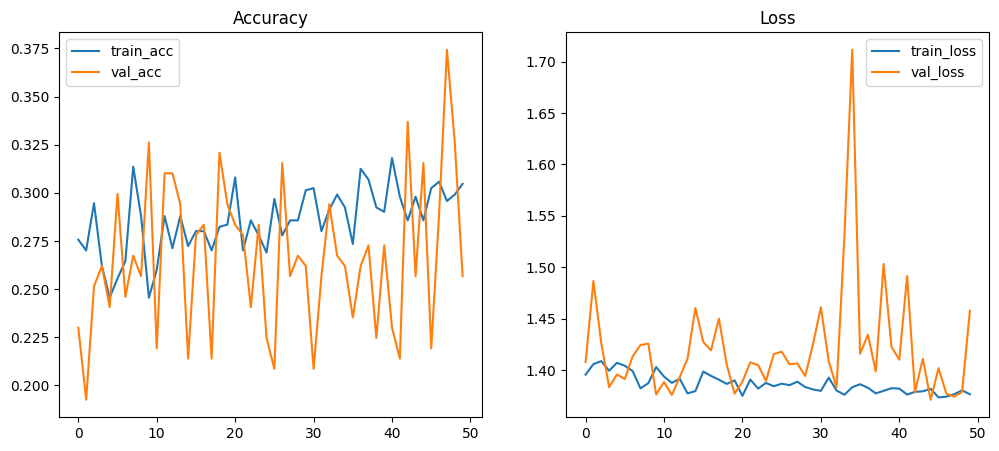

In [13]:
# ====================
# Train model
# ====================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint]
)

# ====================
# Plot accuracy and loss
# ====================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.legend()
plt.show()

In [14]:
best_model = tf.keras.models.load_model("best_model_hc.keras")
best_model.save("model_hc.keras")

In [16]:
model = tf.keras.models.load_model("model_hc.keras")
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# ====================
# Evaluate on test set
# ====================
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3000 - loss: 1.3966
Test Accuracy: 0.30000001192092896


Classes: ['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 693ms/step


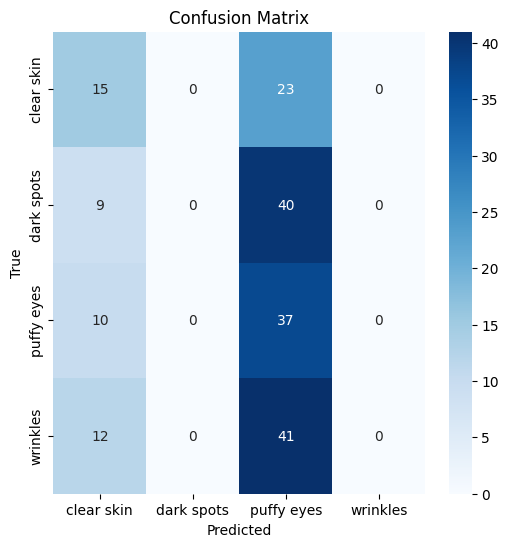

In [19]:
# 2️⃣ Get class names from your folder structure
DATA_DIR = "C:\\Users\\peter\\Documents\\internship\\DATASET"
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print("Classes:", class_names)
# 3️⃣ Collect all test images and labels
test_images, test_labels = [], []

for images, labels in val_ds:  # or your test_ds
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.vstack(test_images)
test_labels = np.vstack(test_labels)

# 4️⃣ Predict classes
pred_probs = model.predict(test_images)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# 5️⃣ Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
